# **Problem Statement**

A retail store that has multiple outlets across the country are facing issues in managing the
inventory - to match the demand with respect to supply.

**Importing the Necessary Libraries**

In [2]:
import pandas as pd #data manipulation
import numpy as np  #numerical python
import matplotlib.pyplot as plt #data visualization
import calendar
%matplotlib inline
import seaborn as sns #data visualization
import plotly.express as px #data visualization
import plotly.graph_objects as go #data visualization
from plotly.subplots import make_subplots #to make subplots
import warnings
warnings.filterwarnings('ignore') #to ignore warnings
import itertools
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

**Importing The Dataset**

In [3]:
data=pd.read_csv('/content/Walmart.csv')

**Interpreting the dataset**

In [4]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


**Dataset Information:**

The walmart.csv contains 6435 rows and 8 columns.

**Feature Name**                      **Description**

**Store**   :-            Store number

**Date**    :-            Week of Sales

**Weekly_Sales**   :-     Sales for the given store in that week

**Holiday_Flag**  :-      If it is a holiday week

**Temperature**    :-      Temperature on the day of the sale

**Fuel_Price**    :-  Cost of the fuel in the region

**CPI**           :-  Consumer Price Index

**Unemployment**  :-  Unemployment Rate

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [7]:
data.duplicated().sum()

0

In [8]:
#convert date column from object type to datetime type

data['Date']=pd.to_datetime(data['Date'],dayfirst=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


# **Exploratory Data Analysis**

In [10]:
#extracting details from Date given,seasonality checks and grouping
data['month']=data['Date'].dt.month
data['year']=data['Date'].dt.year
data['day']=data['Date'].dt.day

#change month values from numbers to real values like jan,feb
data['month']=data['month'].apply(lambda x:calendar.month_abbr[x])

In [11]:
#add a week column for further analysis
data['week']=data['Date'].dt.isocalendar().week

In [12]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,year,day,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,Feb,2010,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,Feb,2010,12,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,Feb,2010,19,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,Feb,2010,26,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,Mar,2010,5,9


In [13]:
#checking relationship b/w weekly_sales and employement
data[['Unemployment','Weekly_Sales']].corr()

,Unemployment,Weekly_Sales
Unemployment,1.000000,-0.106176
Weekly_Sales,-0.106176,1.000000


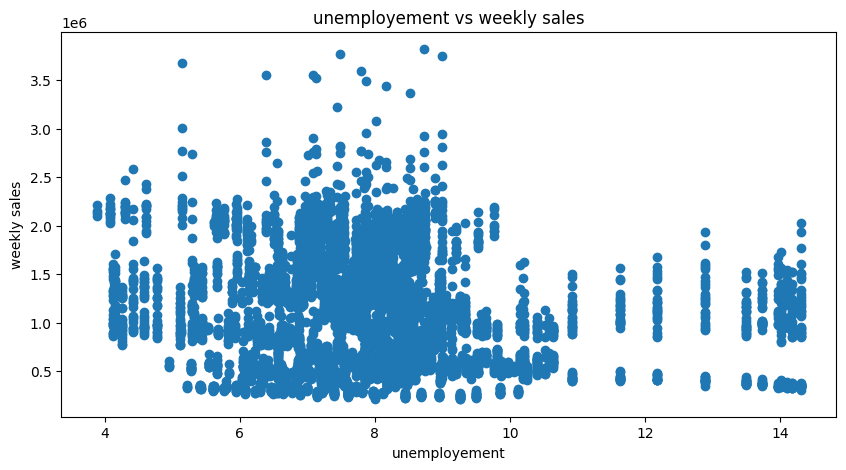

In [14]:
plt.figure(figsize=(10,5))
plt.scatter(x=data['Unemployment'],y=data['Weekly_Sales'])
plt.title('unemployement vs weekly sales')
plt.xlabel('unemployement')
plt.ylabel('weekly sales')
plt.show()

In [15]:


correlation_store_1=data.groupby('Store')[['Weekly_Sales','Unemployment']].corr().unstack().iloc[:,1]
#correlation b/w weekly_sales and employement for all stores
correlation_store_1


,Weekly_Sales
,Unemployment
Store,
1,-0.097955
2,0.066325
3,-0.230413
4,-0.337015
5,-0.207043
6,0.044251
7,-0.165382
8,-0.052580


In [16]:
correlation_store_1=correlation_store_1.sort_values()
print('the most affected 5 stores due to unemployement is:\n',correlation_store_1.iloc[0:5])

the most affected 5 stores due to unemployement is:
 Store
38   -0.785290
44   -0.780076
39   -0.384681
42   -0.356355
41   -0.350630
Name: (Weekly_Sales, Unemployment), dtype: float64


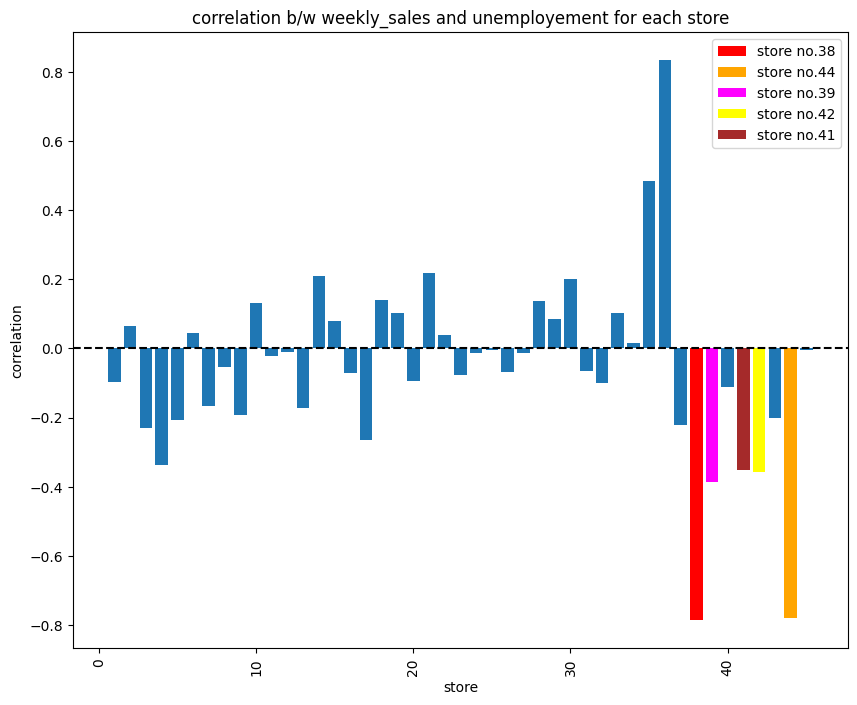

In [17]:
#lets Visualize this
correlation_store_1=correlation_store_1.sort_values()
most_affected_store=correlation_store_1.idxmin()

plt.figure(figsize=(10,8))
plt.bar(correlation_store_1.index,correlation_store_1.values)
plt.bar(correlation_store_1.index[0],correlation_store_1.values[0],color='red',label='store no.38')
plt.bar(correlation_store_1.index[1],correlation_store_1.values[1],color='orange',label='store no.44')
plt.bar(correlation_store_1.index[2],correlation_store_1.values[2],color='magenta',label='store no.39')
plt.bar(correlation_store_1.index[3],correlation_store_1.values[3],color='yellow',label='store no.42')
plt.bar(correlation_store_1.index[4],correlation_store_1.values[4],color='brown',label='store no.41')
plt.axhline(0,color='black',linestyle='--')
plt.legend()
plt.ylabel('correlation')
plt.xlabel('store')
plt.xticks(rotation=90)
plt.title('correlation b/w weekly_sales and unemployement for each store')
plt.show()


The overall correlation between Weekly_Sales and Unemployment across all stores is **-0.106**, indicating **a weak negative relationship**. This suggests that, in general, higher unemployment rates are slightly associated with lower sales, but the effect is not very strong.

However, certain stores are more heavily impacted by unemployment. The top 5 stores most negatively affected by unemployment are:

Store 38: Correlation of -0.785

Store 44: Correlation of -0.780

Store 39: Correlation of -0.385

Store 42: Correlation of -0.356

Store 41: Correlation of -0.351

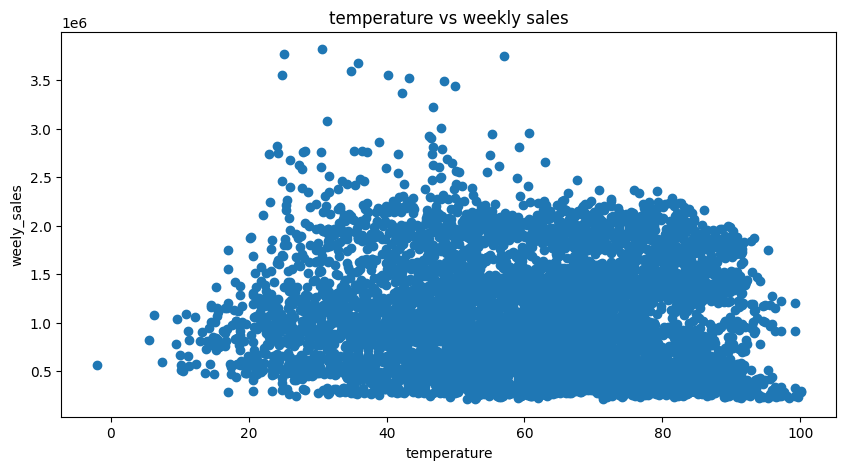

In [18]:
#checking relatioship between temperature and weekly sales
plt.figure(figsize=(10,5))
plt.scatter(x=data['Temperature'],y=data['Weekly_Sales'])
plt.xlabel('temperature')
plt.ylabel('weely_sales')
plt.title('temperature vs weekly sales')
plt.show()

In [19]:
correlation_2=data[['Temperature','Weekly_Sales']].corr()
correlation_2

,Temperature,Weekly_Sales
Temperature,1.00000,-0.06381
Weekly_Sales,-0.06381,1.00000


overall correlation between temperature and weekly_sales is **-0.06381**.indicating a **very weak negative** or almost **no correlation**.

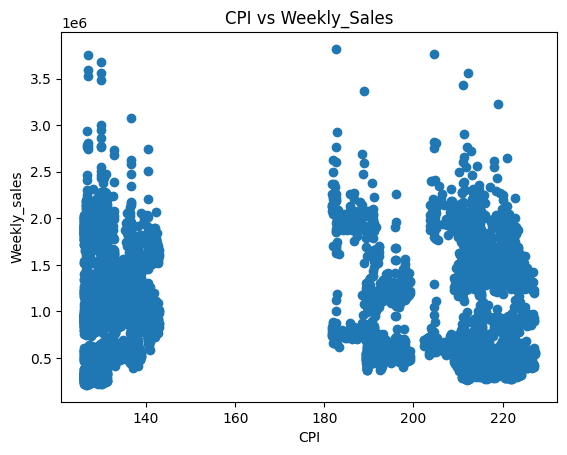

In [20]:
#Checking Relationship between CPI and Weekly_sales
plt.scatter(x=data['CPI'],y=data['Weekly_Sales'])
plt.xlabel('CPI')
plt.ylabel('Weekly_sales')
plt.title('CPI vs Weekly_Sales')
plt.show()



<Axes: >

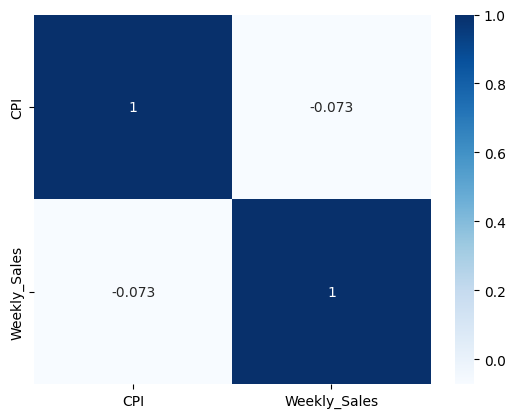

In [21]:
sns.heatmap(data[['CPI','Weekly_Sales']].corr(),annot=True,cmap='Blues')

The overall correlation between Weekly_Sales and CPI across all stores is -0.073, indicating a very weak negative relationship. This suggests that, in general, higher CPI index are slightly associated with lower sales, but the effect is not very strong.




**Best performing and worst performing stores**

In [22]:
#Using total_sales
sales_total=data.groupby('Store')["Weekly_Sales"].sum()
top_5=data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(5)
bottom_5=data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=True).head(5)

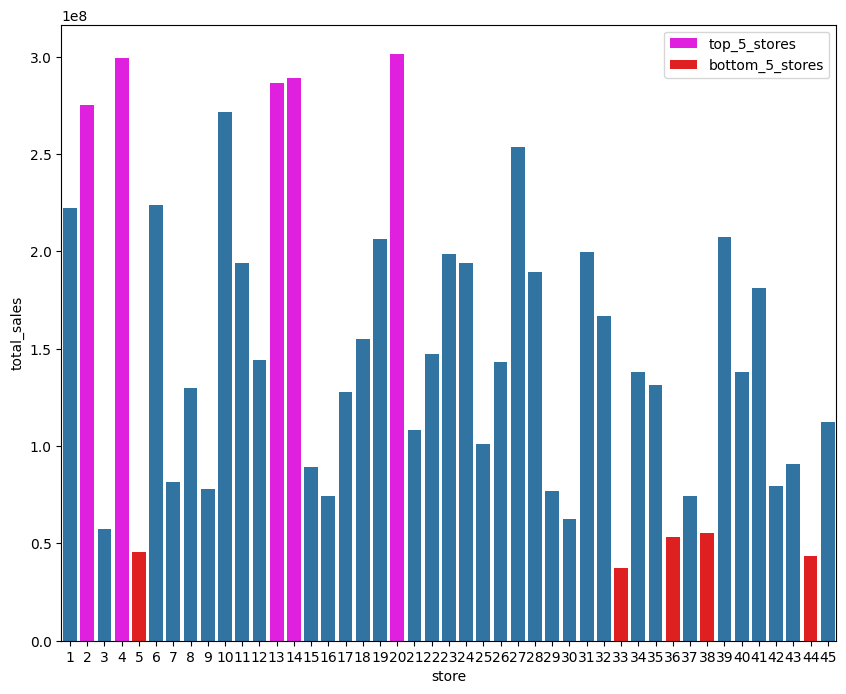

In [23]:
#lets Visualize
plt.figure(figsize=(10,8))
sns.barplot(x=sales_total.index,y=sales_total.values)
sns.barplot(x=top_5.index,y=top_5.values,label='top_5_stores',color='magenta')
sns.barplot(x=bottom_5.index,y=bottom_5.values,label='bottom_5_stores',color='red')
plt.legend()
plt.xlabel('store')
plt.ylabel('total_sales')
plt.show()

**Using Total sales criteria**

**top 5 Best Performing stores**

store no.20

store no.4

store no.14

store no.13

store no.12

**Bottom 5 worst performing stores**

store no.38

store no.36

store no.5

store no.44

store no.33




In [24]:
#using mean sales as criteria
mean_sales=data.groupby('Store')["Weekly_Sales"].mean()
top_5m=data.groupby('Store')["Weekly_Sales"].mean().sort_values(ascending=False).head(5)
bottom_5m=data.groupby('Store')["Weekly_Sales"].mean().sort_values(ascending=True).head(5)

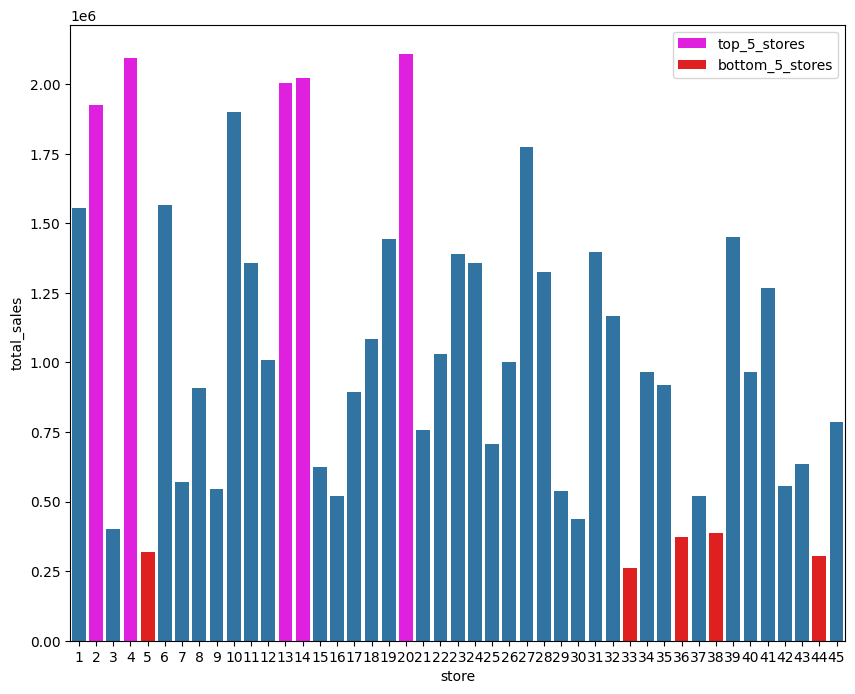

In [25]:
#lets Visualize this
plt.figure(figsize=(10,8))
sns.barplot(x=mean_sales.index,y=mean_sales.values)
sns.barplot(x=top_5m.index,y=top_5m.values,label='top_5_stores',color='magenta')
sns.barplot(x=bottom_5m.index,y=bottom_5m.values,label='bottom_5_stores',color='red')
plt.legend()
plt.xlabel('store')
plt.ylabel('total_sales')
plt.show()


**Using mean sales criteria**

**top 5 Best Performing stores**

store no.20

store no.4

store no.14

store no.13

store no.12

**Bottom 5 worst performing stores**

store no.38

store no.36

store no.5

store no.44

store no.33

**Top and Bottom performing stores**

In [26]:
print(f'the top performing store is 20 with total_sales={top_5.values[0]} and avg_sales={top_5m.values[0]}')
print(f'worst performing store is 33 with total_sales={bottom_5.values[0]} and avg_sales={bottom_5m.values[0]}')

the top performing store is 20 with total_sales=301397792.46 and avg_sales=2107676.8703496503
worst performing store is 33 with total_sales=37160221.96 and avg_sales=259861.69202797202


In [27]:
difference_in_total_sales=top_5.values[0]-bottom_5.values[0]
difference_in_avg_sales=top_5m.values[0]-bottom_5m.values[0]
print(f'differnce between top and worst performing store wrt total sales={difference_in_total_sales}')
print(f'differnce between top and worst performing wrt store avg sales={difference_in_avg_sales}')

differnce between top and worst performing store wrt total sales=264237570.49999997
differnce between top and worst performing wrt store avg sales=1847815.1783216782


**Check for seasonality and trends**

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [29]:
data.set_index('Date',inplace=True)
data.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,year,day,week
Date,,,,,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106,Feb,2010,5,5
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106,Feb,2010,12,6
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106,Feb,2010,19,7
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106,Feb,2010,26,8
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106,Mar,2010,5,9


<Figure size 640x480 with 0 Axes>

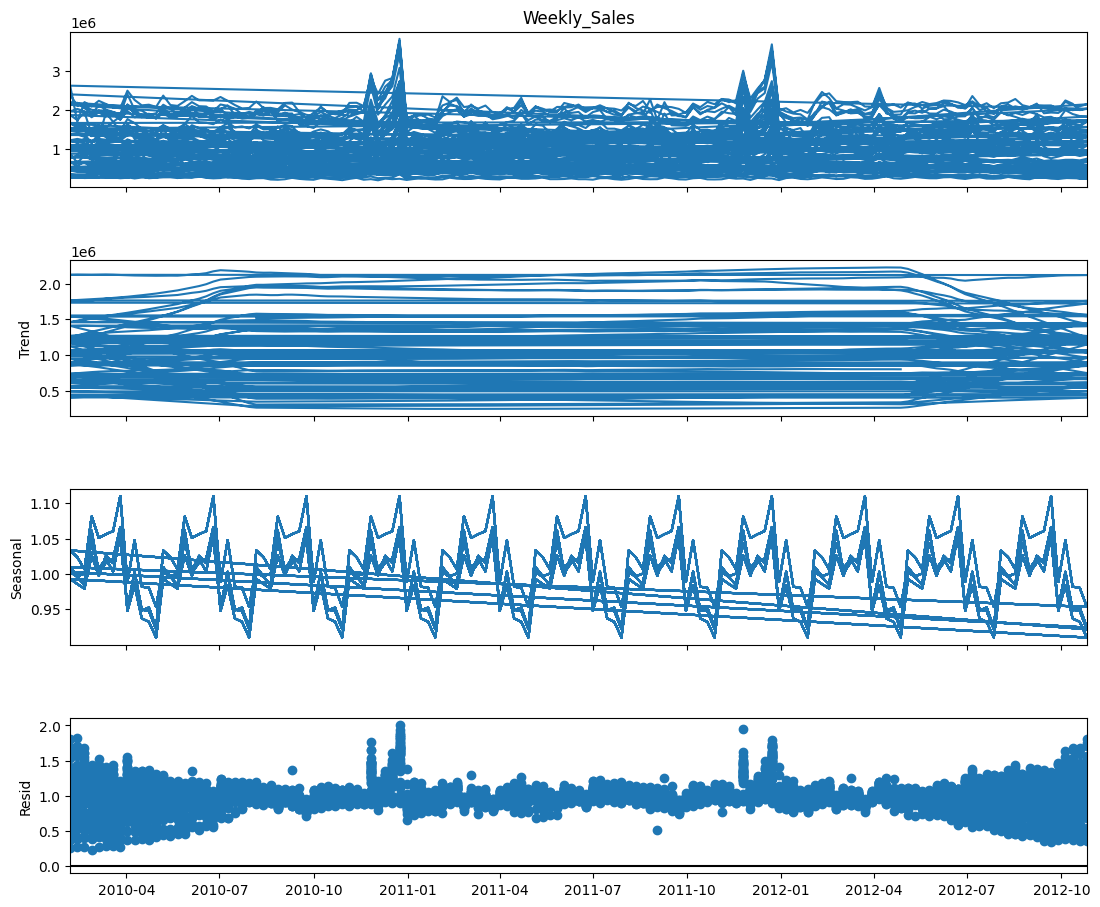

In [30]:
decompose_result=seasonal_decompose(data['Weekly_Sales'],period=52,model='multiplicative')
fig=plt.figure()
fig=decompose_result.plot()
fig.set_size_inches(12,10)
plt.show()


seasonality is present in weekly_sales let's analyze further

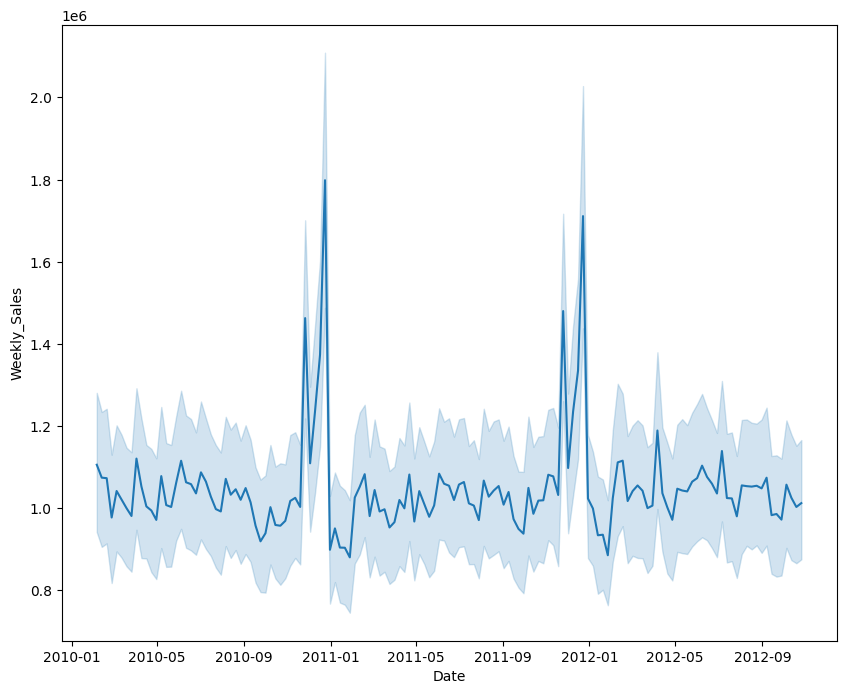

In [31]:
plt.figure(figsize=(10,8))
sns.lineplot(x=data.index,y=data['Weekly_Sales'])
plt.show()

An observable and consistent seasonal pattern emerges,revealing a recurrent surge in weekly sales year by year,commencing in mid nov and extending through to december.The reason could be the increased public demend during the holiday season.

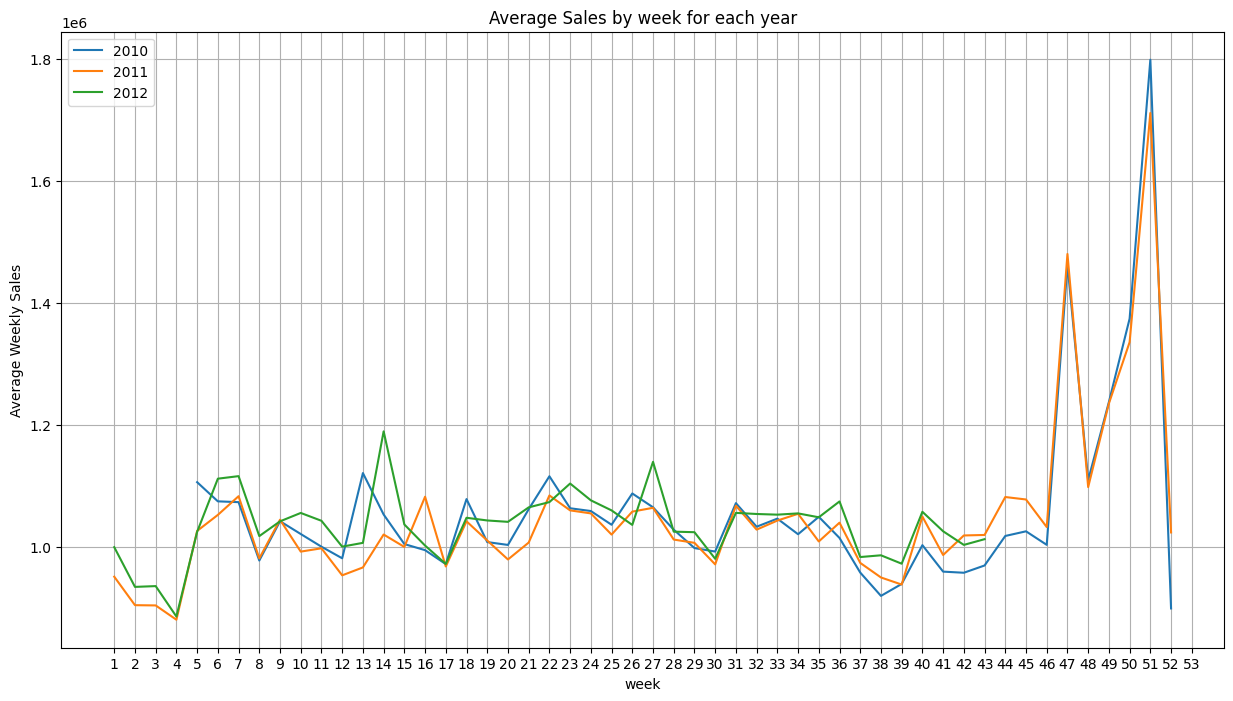

In [32]:
#lets examine avg weekly sales by week for every year
weekly_sales_2010=data[data['year']==2010].groupby('week')['Weekly_Sales'].mean()
weekly_sales_2011=data[data['year']==2011].groupby('week')['Weekly_Sales'].mean()
weekly_sales_2012=data[data['year']==2012].groupby('week')['Weekly_Sales'].mean()
plt.figure(figsize=(15,8))
sns.lineplot(x=weekly_sales_2010.index, y=weekly_sales_2010.values,label='2010')
sns.lineplot(x=weekly_sales_2011.index, y=weekly_sales_2011.values,label='2011')
sns.lineplot(x=weekly_sales_2012.index, y=weekly_sales_2012.values,label='2012')
plt.title('Average Sales by week for each year')
plt.grid()
plt.xlabel('week')
plt.xticks(range(1,54))
plt.ylabel('Average Weekly Sales')
plt.show()

1.from above we see a surge in avg weekly sales around week 47.This sudden increase could be due to holiday shopping effect where consumers increase purchases for holiday celebrations and festivals such as thanksgiving.


2.the weekly sales surge around week 51 this could be due to christmas holidays.




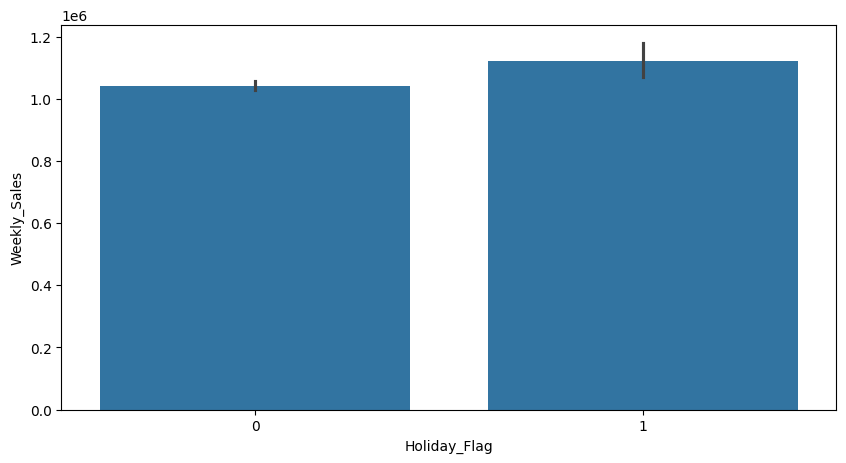

In [33]:
#lets check the effect of holidays on weekly_sales
plt.figure(figsize=(10,5))
sns.barplot(x=data['Holiday_Flag'],y=data['Weekly_Sales'])
plt.show()

from above it is evident that weekly_sales during holidays outperforms weekly_sales during normal days.

# **Sales Forecating for Various Stores**

# **store 5**

In [34]:
store_5=data[data['Store']==5]
store_5

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,year,day,week
Date,,,,,,,,,,,
2010-02-05,5,317173.10,0,39.70,2.572,211.653972,6.566,Feb,2010,5,5
2010-02-12,5,311825.70,1,39.81,2.548,211.800470,6.566,Feb,2010,12,6
2010-02-19,5,303447.57,0,41.14,2.514,211.847128,6.566,Feb,2010,19,7
2010-02-26,5,270281.63,0,46.70,2.561,211.877147,6.566,Feb,2010,26,8
2010-03-05,5,288855.71,0,48.89,2.625,211.907165,6.566,Mar,2010,5,9
...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,5,310141.68,0,78.33,3.666,223.574102,5.603,Sep,2012,28,39
2012-10-05,5,343048.29,0,71.17,3.617,223.774444,5.422,Oct,2012,5,40
2012-10-12,5,325345.41,0,66.24,3.601,223.974787,5.422,Oct,2012,12,41


In [35]:

sales_5= pd.DataFrame(store_5.groupby(store_5.index)['Weekly_Sales'].sum())
sales_5.head()


,Weekly_Sales
Date,
2010-02-05,317173.10
2010-02-12,311825.70
2010-02-19,303447.57
2010-02-26,270281.63
2010-03-05,288855.71


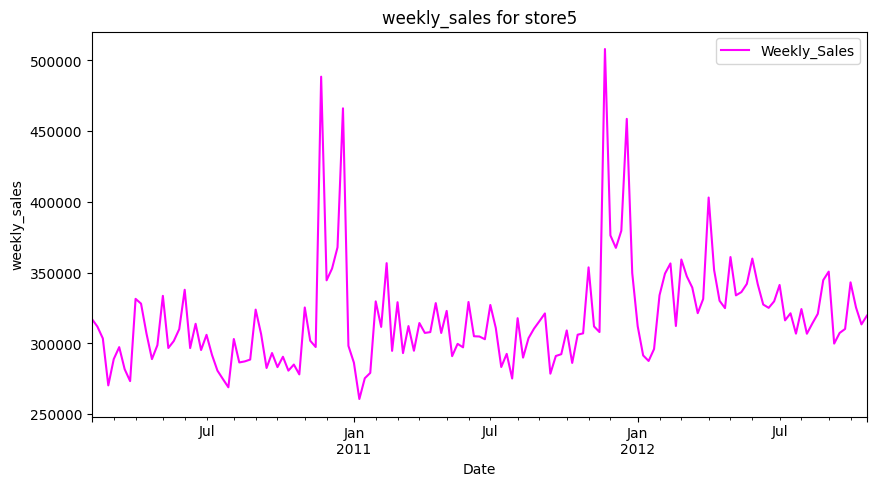

In [36]:
#lets plot the yearly sales of store_5
sales_5.plot(figsize=(10,5),title='weekly_sales for store5',color='magenta')
plt.ylabel('weekly_sales')
plt.show()

In [37]:
#check for stationarity
from statsmodels.tsa.stattools import adfuller
result=adfuller(sales_5['Weekly_Sales'])
print(result)

(-4.310974424060915, 0.00042517056141923293, 4, 138, {'1%': -3.47864788917503, '5%': -2.882721765644168, '10%': -2.578065326612056}, 3038.49592982281)


In [39]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.9 MB/s eta 0:00:00


the data is stationary p-value is less than 0.05 reject the null hypothesis

In [65]:
#calculating the value of p,d,q
from pmdarima import auto_arima
arima_model=auto_arima(sales_5['Weekly_Sales'],seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3427.452, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3410.502, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3400.127, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3425.456, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3397.113, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3398.646, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3398.543, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=3398.442, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3405.850, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=3395.851, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=3398.350, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=3408.507, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=3397.068, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0]             : 

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX,SARIMAXResults

In [42]:
model_1=SARIMAX(sales_5,order=(1,1,1),seasonal_order=(1,1,1,52),enforce_invertibility=False)
model_1=model_1.fit()
model_1.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1019.156
Date:                            Tue, 10 Sep 2024   AIC                           2048.312
Time:                                    17:11:49   BIC                           2060.811
Sample:                                02-05-2010   HQIC                          2053.352
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7455      0.093      7.984      0.000       0.562       0.928
ma.L1         -1.2113      0.111    -10.953      0.000      -1.428      -0.995
ar.S.L52       0.5655      0.300      1.885      0.059      -0.022       1.153
ma.S.L52      -0.8358      0.502     -1.664      0.096      -1.820       0.148
sigma2      2.844e+08   1.02e-09   2.79e+17      0.000    2.84e+08    2.84e+08
===================================================================================
Ljung-Box (L1) (Q):                  11.44   Jarque-Bera (JB):                14.29
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.40
Prob(H) (two-sided):                  0.90   Kurtosis:                         4.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.31e+33. Standard errors may be unstable.
"""

In [43]:
#using last 3 months for prediction
pred_1=model_1.get_prediction(start=pd.to_datetime('2012-07-27'),dynamic=False)
pred_ci_1=pred_1.conf_int()

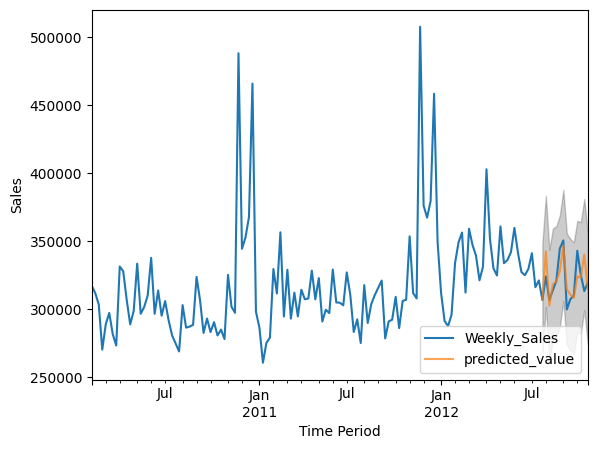

In [44]:
#plotting the actual and predicted values
ax = sales_5['2010':].plot(label='observed')
pred_1.predicted_mean.plot(ax=ax, label='predicted_value', alpha=.7)

ax.fill_between(pred_ci_1.index,
                pred_ci_1.iloc[:, 0],
                pred_ci_1.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.legend()

plt.show()

In [45]:
# calculating the root mean square error
predict_1=pred_1.predicted_mean
actual_1=sales_5.loc['2012-07-27':]
rmse_1=np.sqrt(mean_squared_error(actual_1,predict_1))
print('the root mean square error is :',rmse_1)

the root mean square error is : 11962.02946593158


In [46]:
#forecasting for next 3 months
# Forecast sales for the next 3 months (12 future steps)
forecast_1 =model_1.get_forecast(steps=12)

# Get the predicted mean values (the actual forecasted sales)
forecast_mean_1 = forecast_1.predicted_mean

# Get confidence intervals for the forecast
forecast_conf_int_1 = forecast_1.conf_int()

# Display the forecasted values
print(forecast_mean_1)
print("*******************************")
print(forecast_conf_int_1)

2012-11-02    360013.626892
2012-11-09    326264.492279
2012-11-16    323324.538798
2012-11-23    493516.615515
2012-11-30    380876.044350
2012-12-07    375009.153452
2012-12-14    386019.288801
2012-12-21    455305.567496
2012-12-28    359155.964533
2013-01-04    329941.927852
2013-01-11    313326.184353
2013-01-18    313010.618269
Freq: W-FRI, Name: predicted_mean, dtype: float64
*******************************
            lower Weekly_Sales  upper Weekly_Sales
2012-11-02       319093.465172       400933.788613
2012-11-09       270662.974027       381866.010530
2012-11-16       257516.607781       389132.469814
2012-11-23       419726.599918       567306.631112
2012-11-30       300436.826066       461315.262635
2012-12-07       288799.102924       461219.203980
2012-12-14       294653.899748       477384.677854
2012-12-21       359236.154858       551374.980134
2012-12-28       258725.813017       459586.116049
2013-01-04       225420.506381       434463.349324
2013-01-11       2049

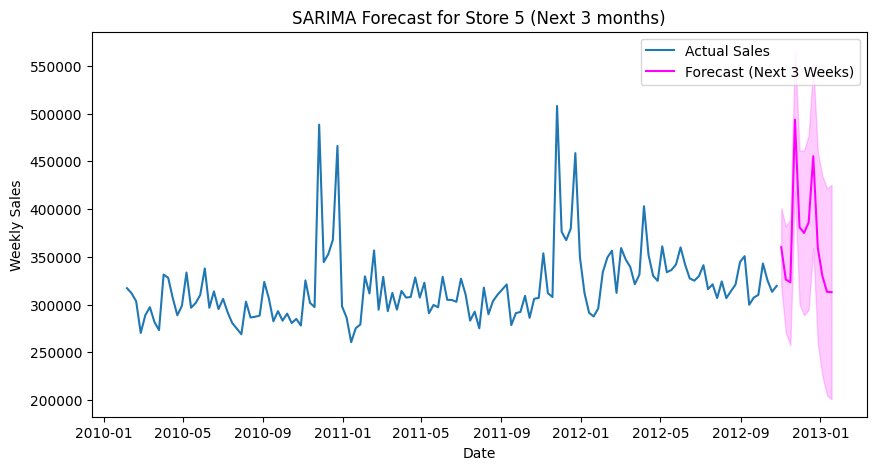

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(sales_5, label='Actual Sales')
plt.plot(forecast_mean_1, label='Forecast (Next 3 Weeks)', color='magenta')
plt.fill_between(forecast_mean_1.index,
                 forecast_conf_int_1.iloc[:, 0],
                 forecast_conf_int_1.iloc[:, 1], color='magenta', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('SARIMA Forecast for Store 5 (Next 3 months)')
plt.legend()
plt.show()


**Store 16**

In [48]:
#filtering records for store 16
store_16=data[data['Store']==16]
store_16

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,year,day,week
Date,,,,,,,,,,,
2010-02-05,16,477409.30,0,19.79,2.580,189.381697,7.039,Feb,2010,5,5
2010-02-12,16,472044.28,1,20.87,2.572,189.464272,7.039,Feb,2010,12,6
2010-02-19,16,469868.70,0,21.13,2.550,189.534100,7.039,Feb,2010,19,7
2010-02-26,16,443242.17,0,18.12,2.586,189.601802,7.039,Feb,2010,26,8
2010-03-05,16,444181.85,0,27.92,2.620,189.669505,7.039,Mar,2010,5,9
...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,16,469607.73,0,51.40,3.789,198.590328,6.061,Sep,2012,28,39
2012-10-05,16,471281.68,0,50.46,3.779,198.822132,5.847,Oct,2012,5,40
2012-10-12,16,491817.19,0,43.26,3.760,199.053937,5.847,Oct,2012,12,41


In [49]:
# weekly_sales for store 16
sales_16=pd.DataFrame(store_16.groupby(store_16.index)['Weekly_Sales'].sum())
sales_16

,Weekly_Sales
Date,
2010-02-05,477409.30
2010-02-12,472044.28
2010-02-19,469868.70
2010-02-26,443242.17
2010-03-05,444181.85
...,...
2012-09-28,469607.73
2012-10-05,471281.68
2012-10-12,491817.19


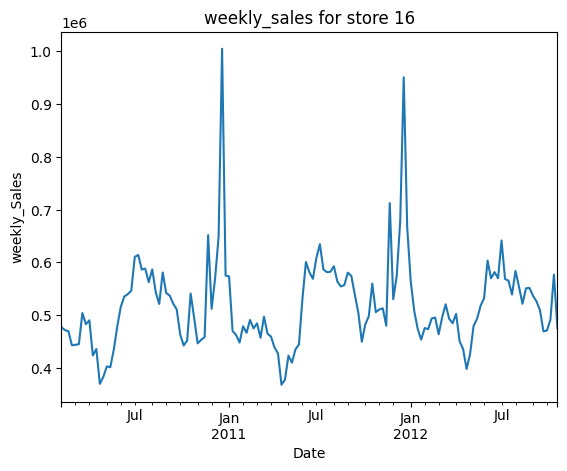

In [50]:
#weekly_Sales for store 16 with time
sales_16['Weekly_Sales'].plot(title='weekly_sales for store 16')
plt.ylabel('weekly_Sales')
plt.show()

In [51]:
#check for Stationarity
result_2=adfuller(sales_16['Weekly_Sales'])
print(result_2)

(-4.525758298011167, 0.00017660674414720552, 4, 138, {'1%': -3.47864788917503, '5%': -2.882721765644168, '10%': -2.578065326612056}, 3213.497862329278)


P-value is less than 0.05 hence we reject the null hypothesis.
the data is stationary

In [52]:
from pmdarima import auto_arima
arima_model_2=auto_arima(sales_16['Weekly_Sales'],seasonal=True,Trace=True)
arima_model_2

ARIMA(order=(2, 0, 0), scoring_args={}, suppress_warnings=True)

In [53]:
model_2=SARIMAX(sales_16,order=(2,0,0),seasonal_order=(2,0,0,52),enforce_invertibility=False)
model_2=model_2.fit()
model_2.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 52)   Log Likelihood               -1776.581
Date:                            Tue, 10 Sep 2024   AIC                           3563.161
Time:                                    17:13:09   BIC                           3577.976
Sample:                                02-05-2010   HQIC                          3569.181
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6279      0.087      7.210      0.000       0.457       0.799
ar.L2          0.3482      0.108      3.218      0.001       0.136       0.560
ar.S.L52       0.6475      0.810      0.799      0.424      -0.940       2.235
ar.S.L104      0.0289      1.178      0.025      0.980      -2.281       2.339
sigma2      5.227e+09   5.53e-11   9.45e+19      0.000    5.23e+09    5.23e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.30   Jarque-Bera (JB):              1297.61
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               0.22   Skew:                             1.33
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.64e+36. Standard errors may be unstable.
"""

In [54]:
pred_2=model_2.get_prediction(start=pd.to_datetime('2012-07-27'),dynamic=False)
pred_ci_2=pred_2.conf_int()

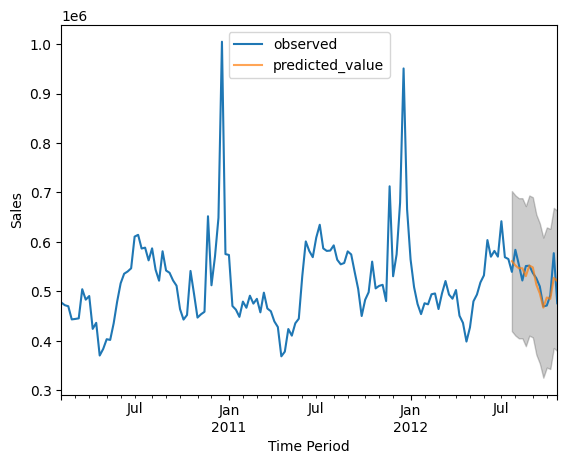

In [62]:
sales_16['Weekly_Sales'].plot(label='observed')
pred_2.predicted_mean.plot(label='predicted_value', alpha=.7)

plt.fill_between(pred_ci_2.index,
                pred_ci_2.iloc[:, 0],
                pred_ci_2.iloc[:, 1], color='k', alpha=.2)

plt.xlabel('Time Period')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [56]:
predict_2=pred_2.predicted_mean
actual_2=sales_16.loc['2012-07-27':]
rmse_2=np.sqrt(mean_squared_error(actual_2,predict_2))
print('the root mean square error is :',rmse_2)

the root mean square error is : 23824.30161531321


In [57]:
#forecasting for next 3 months
# Forecast sales for the next 3 months (12 future steps)
forecast_2 =model_2.get_forecast(steps=12)

# Get the predicted mean values (the actual forecasted sales)
forecast_mean_2 = forecast_2.predicted_mean

# Get confidence intervals for the forecast
forecast_conf_int_2 = forecast_2.conf_int()

# Display the forecasted values
print(forecast_mean_2)
print("*******************************")
print(forecast_conf_int_2)

2012-11-02    497149.329486
2012-11-09    488286.248508
2012-11-16    467395.402153
2012-11-23    619757.375747
2012-11-30    495801.478927
2012-12-07    523617.403663
2012-12-14    591337.377676
2012-12-21    774895.680473
2012-12-28    575752.653453
2013-01-04    507835.515179
2013-01-11    466363.337904
2013-01-18    441869.909327
Freq: W-FRI, Name: predicted_mean, dtype: float64
*******************************
            lower Weekly_Sales  upper Weekly_Sales
2012-11-02       355447.057275        6.388516e+05
2012-11-09       320967.835396        6.556047e+05
2012-11-16       269747.720139        6.650431e+05
2012-11-23       399571.352285        8.399434e+05
2012-11-30       254966.047865        7.366369e+05
2012-12-07       264701.634233        7.825332e+05
2012-12-14       316001.480902        8.666733e+05
2012-12-21       484624.408010        1.065167e+06
2012-12-28       271752.463515        8.797528e+05
2013-01-04       191153.565858        8.245175e+05
2013-01-11       1379

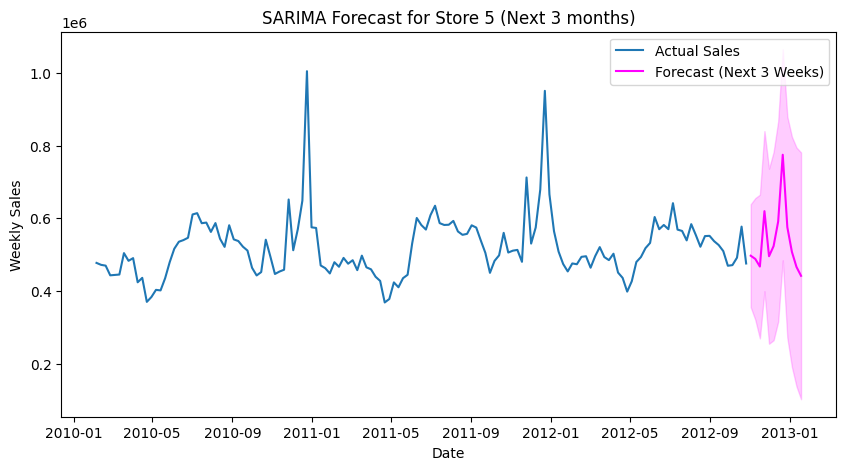

In [64]:
#plotting the forecasted_values
plt.figure(figsize=(10, 5))
plt.plot(sales_16, label='Actual Sales')
plt.plot(forecast_mean_2, label='Forecast (Next 3 Weeks)', color='magenta')
plt.fill_between(forecast_conf_int_2.index,
                 forecast_conf_int_2.iloc[:, 0],
                 forecast_conf_int_2.iloc[:, 1], color='magenta', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('SARIMA Forecast for Store 5 (Next 3 months)')
plt.legend()
plt.show()

# **store 40**

In [66]:
#filtering records for store 40
store_40=data[data['Store']==40]
store_40

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,month,year,day,week
Date,,,,,,,,,,,
2010-02-05,40,1001943.80,0,14.48,2.788,131.527903,5.892,Feb,2010,5,5
2010-02-12,40,955338.29,1,20.84,2.771,131.586613,5.892,Feb,2010,12,6
2010-02-19,40,916289.20,0,27.84,2.747,131.637000,5.892,Feb,2010,19,7
2010-02-26,40,863917.41,0,33.32,2.753,131.686000,5.892,Feb,2010,26,8
2010-03-05,40,990152.28,0,34.78,2.766,131.735000,5.892,Mar,2010,5,9
...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,40,919595.44,0,50.98,4.018,138.739500,4.156,Sep,2012,28,39
2012-10-05,40,1069112.00,0,57.21,4.027,138.825600,4.145,Oct,2012,5,40
2012-10-12,40,982523.26,0,47.35,4.029,138.911700,4.145,Oct,2012,12,41


In [67]:
# weekly_sales for store 40
sales_40=pd.DataFrame(store_40.groupby(store_40.index)['Weekly_Sales'].sum())
sales_40

,Weekly_Sales
Date,
2010-02-05,1001943.80
2010-02-12,955338.29
2010-02-19,916289.20
2010-02-26,863917.41
2010-03-05,990152.28
...,...
2012-09-28,919595.44
2012-10-05,1069112.00
2012-10-12,982523.26


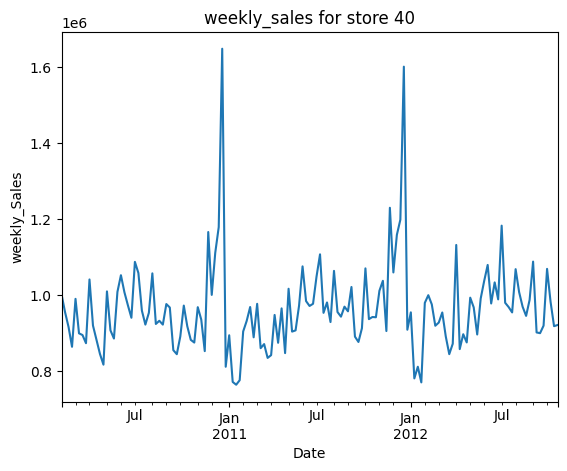

In [68]:
#weekly_Sales for store 40 with time
sales_40['Weekly_Sales'].plot(title='weekly_sales for store 40')
plt.ylabel('weekly_Sales')
plt.show()

In [69]:
#check for Stationarity
result_3=adfuller(sales_40['Weekly_Sales'])
print(result_3)

(-5.381704099293347, 3.7001648560085984e-06, 4, 138, {'1%': -3.47864788917503, '5%': -2.882721765644168, '10%': -2.578065326612056}, 3348.5691234301335)


**p value is less than 0.05 hence data is stationary**

In [70]:
# estimating the value of p,d,q
from pmdarima import auto_arima
arima_model_3=auto_arima(sales_40['Weekly_Sales'],seasonal=True,Trace=True)
arima_model_3

ARIMA(order=(0, 0, 4), scoring_args={}, suppress_warnings=True)

In [72]:
#Modelling
model_3=SARIMAX(sales_40,order=(0,0,4),seasonal_order=(0,0,4,52),enforce_invertibility=False)
model_3=model_3.fit()
model_3.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(0, 0, 4)x(0, 0, 4, 52)   Log Likelihood               -2108.960
Date:                            Tue, 10 Sep 2024   AIC                           4235.920
Time:                                    17:35:37   BIC                           4262.585
Sample:                                02-05-2010   HQIC                          4246.755
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.2632      1.021      1.237      0.216      -0.738       3.264
ma.L2          1.2982      1.320      0.984      0.325      -1.288       3.885
ma.L3          0.8456      1.550      0.546      0.585      -2.192       3.884
ma.L4          0.4568      1.245      0.367      0.714      -1.983       2.896
ma.S.L52       0.1006    156.171      0.001      0.999    -305.988     306.189
ma.S.L104      0.0254   1189.270   2.14e-05      1.000   -2330.902    2330.953
ma.S.L156      0.0041   9312.652   4.39e-07      1.000   -1.83e+04    1.83e+04
ma.S.L208      0.0008   9989.417   7.81e-08      1.000   -1.96e+04    1.96e+04
sigma2      9.457e+11      0.001   8.46e+14      0.000    9.46e+11    9.46e+11
===================================================================================
Ljung-Box (L1) (Q):                  32.41   Jarque-Bera (JB):               243.97
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.74   Skew:                            -1.14
Prob(H) (two-sided):                  0.30   Kurtosis:                         8.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.41e+30. Standard errors may be unstable.
"""

In [73]:
#predicting on last 3 months
pred_3=model_3.get_prediction(start=pd.to_datetime('2012-07-27'),dynamic=False)
pred_ci_3=pred_3.conf_int()

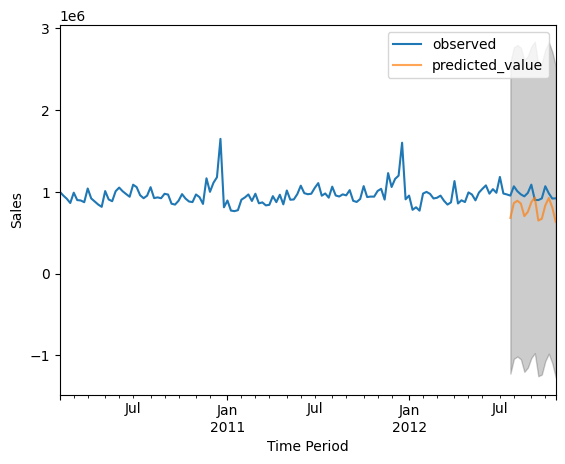

In [75]:
sales_40['Weekly_Sales'].plot(label='observed')
pred_3.predicted_mean.plot(label='predicted_value', alpha=.7)

plt.fill_between(pred_ci_3.index,
                pred_ci_3.iloc[:, 0],
                pred_ci_3.iloc[:, 1], color='k', alpha=.2)

plt.xlabel('Time Period')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [76]:
#calculating RMSE
predict_3=pred_3.predicted_mean
actual_3=sales_40.loc['2012-07-27':]
rmse_3=np.sqrt(mean_squared_error(actual_3,predict_3))
print('the root mean square error is :',rmse_3)

the root mean square error is : 203794.9041094556


In [77]:
#forecasting for next 3 months
# Forecast sales for the next 3 months (12 future steps)
forecast_3 =model_3.get_forecast(steps=12)

# Get the predicted mean values (the actual forecasted sales)
forecast_mean_3 = forecast_3.predicted_mean

# Get confidence intervals for the forecast
forecast_conf_int_3 = forecast_3.conf_int()

# Display the forecasted values
print(forecast_mean_3)
print("*******************************")
print(forecast_conf_int_3)

2012-11-02    779122.971154
2012-11-09    612956.436548
2012-11-16    398859.242991
2012-11-23    273971.556229
2012-11-30    121910.997315
2012-12-07    133565.841261
2012-12-14    138622.878047
2012-12-21    186341.514644
2012-12-28    103843.650391
2013-01-04    109710.833856
2013-01-11     90324.879040
2013-01-18     93304.453786
Freq: W-FRI, Name: predicted_mean, dtype: float64
*******************************
            lower Weekly_Sales  upper Weekly_Sales
2012-11-02       -1.126907e+06        2.685153e+06
2012-11-09       -2.457907e+06        3.683820e+06
2012-11-16       -3.544809e+06        4.342527e+06
2012-11-23       -3.986348e+06        4.534291e+06
2012-11-30       -4.226455e+06        4.470277e+06
2012-12-07       -4.214800e+06        4.481932e+06
2012-12-14       -4.209743e+06        4.486989e+06
2012-12-21       -4.162025e+06        4.534708e+06
2012-12-28       -4.244523e+06        4.452210e+06
2013-01-04       -4.238655e+06        4.458077e+06
2013-01-11       -4.2

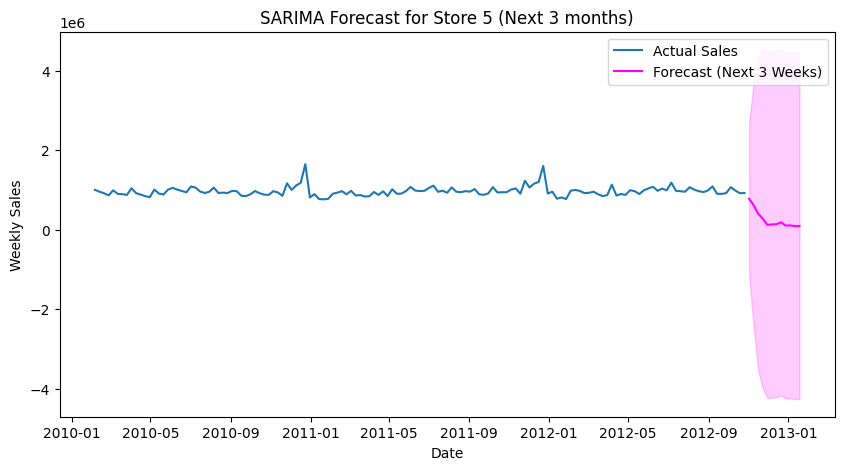

In [78]:
#plotting the forecasted_values
plt.figure(figsize=(10, 5))
plt.plot(sales_40, label='Actual Sales')
plt.plot(forecast_mean_3, label='Forecast (Next 3 Weeks)', color='magenta')
plt.fill_between(forecast_conf_int_3.index,
                 forecast_conf_int_3.iloc[:, 0],
                 forecast_conf_int_3.iloc[:, 1], color='magenta', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('SARIMA Forecast for Store 5 (Next 3 months)')
plt.legend()
plt.show()